In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("fashion_trend_data.csv")
print(df)

In [ ]:
df

In [ ]:
import pandas as pd
import plotly.express as px
# Convert date columns to datetime format
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['End_Date'] = pd.to_datetime(df['End_Date'])

### 1️⃣ Trending Fashion Categories Over Time ###
category_trends = df.groupby(['Start_Date', 'Category']).size().reset_index(name='Count')
fig1 = px.line(category_trends, x="Start_Date", y="Count", color="Category",
               title="🔥 Trending Fashion Categories Over Time")
fig1.show()

In [ ]:
### 2️⃣ Influencer Impact on Fashion Trends ###
fig2 = px.scatter(df, x="Followers", y="Engagement_Rate", color="Platform",
                  size="Avg_Likes", hover_data=["Influencer"],
                  title="📣 Influencer Impact on Fashion Trends")
fig2.show()

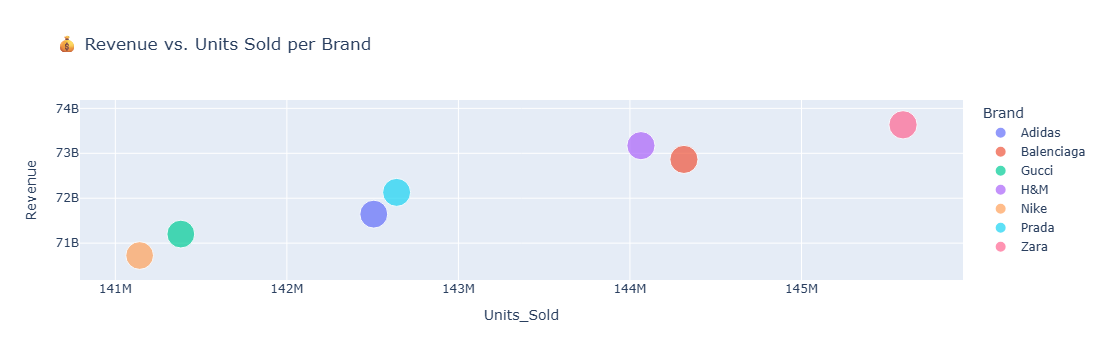

In [20]:
### 3️⃣ Revenue vs. Units Sold per Brand ###
brand_performance = df.groupby("Brand").agg({"Revenue": "sum", "Units_Sold": "sum"}).reset_index()
fig3 = px.scatter(brand_performance, x="Units_Sold", y="Revenue", size="Revenue", color="Brand",
                  title="💰 Revenue vs. Units Sold per Brand", hover_name="Brand")
fig3.show()

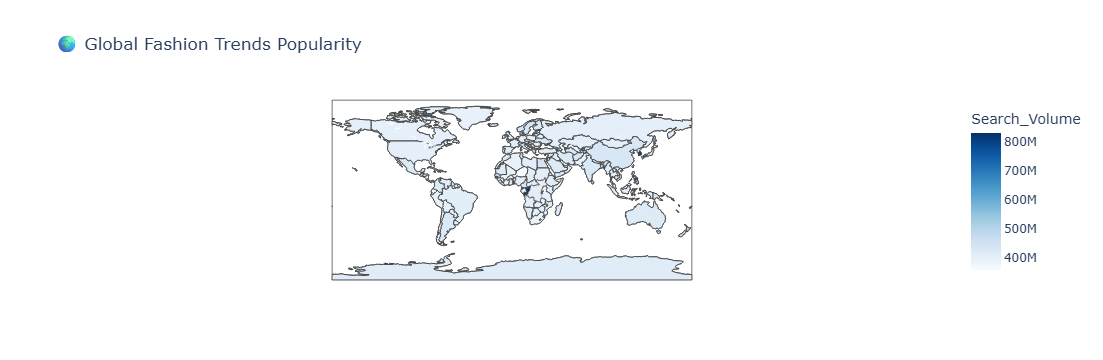

In [22]:
### 4️⃣ Global Fashion Trends Map ###
country_trends = df.groupby("Region").agg({"Search_Volume": "sum"}).reset_index()
fig4 = px.choropleth(country_trends, locations="Region", locationmode="country names",
                     color="Search_Volume", title="🌍 Global Fashion Trends Popularity",
                     color_continuous_scale="blues")
fig4.show()

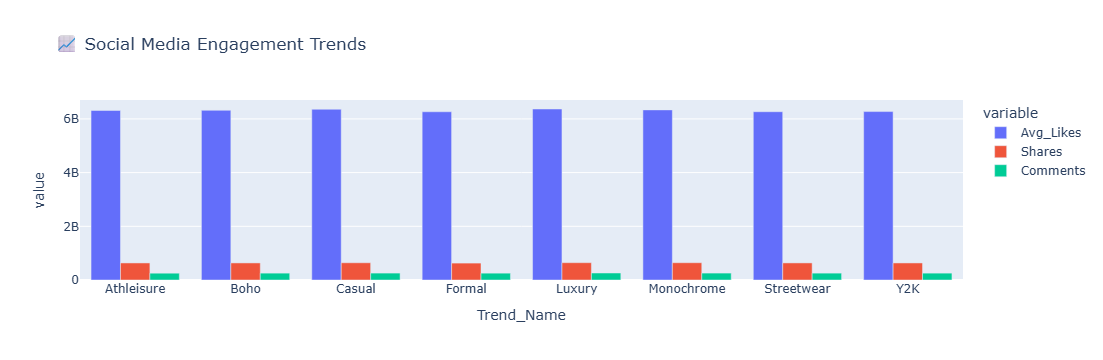

In [24]:
### 5️⃣ Social Media Engagement Trends ###
engagement_metrics = df.groupby("Trend_Name").agg({"Avg_Likes": "sum", "Shares": "sum", "Comments": "sum"}).reset_index()
fig5 = px.bar(engagement_metrics, x="Trend_Name", y=["Avg_Likes", "Shares", "Comments"],
              title="📈 Social Media Engagement Trends", barmode="group")
fig5.show()

In [28]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Convert date columns to datetime format
#df['Start_Date'] = pd.to_datetime(df['Start_Date'])
#df['End_Date'] = pd.to_datetime(df['End_Date'])

### 1️⃣ Fashion Trends Popularity Over Time (Animated Bar Chart) ###
trend_time = df.groupby(['Start_Date', 'Trend_Name']).size().reset_index(name='Count')
fig1 = px.bar(trend_time, x="Trend_Name", y="Count", animation_frame="Start_Date",
              color="Trend_Name", title="🔥 Fashion Trends Popularity Over Time")
fig1.show()

ModuleNotFoundError: No module named 'wordcloud'

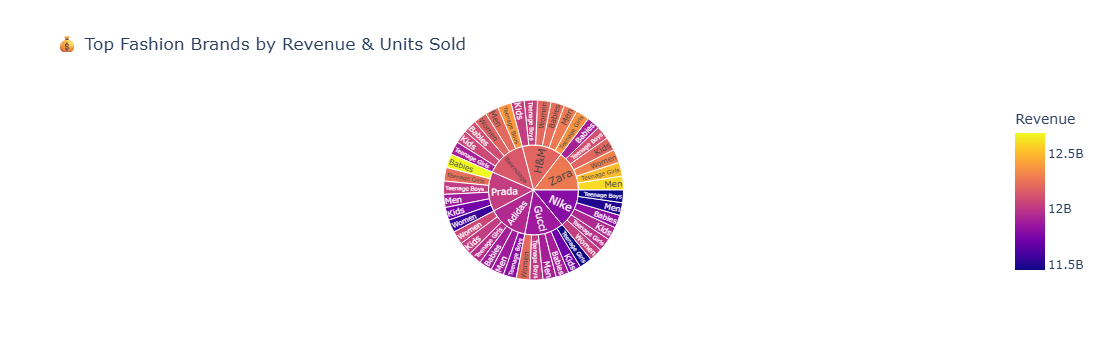

In [30]:
### 2️⃣ Top Fashion Brands by Revenue & Units Sold (Sunburst Chart) ###
brand_data = df.groupby(["Brand", "Category"]).agg({"Revenue": "sum", "Units_Sold": "sum"}).reset_index()
fig2 = px.sunburst(brand_data, path=["Brand", "Category"], values="Revenue",
                   title="💰 Top Fashion Brands by Revenue & Units Sold", color="Revenue")
fig2.show()

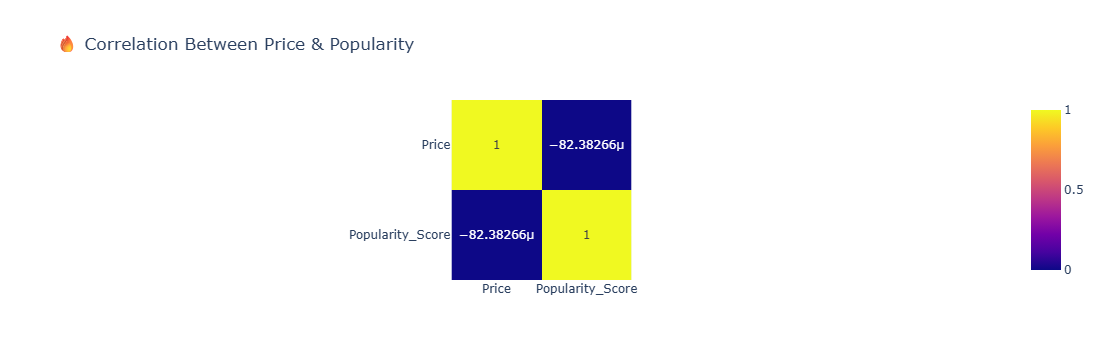

In [32]:
### 4️⃣ Correlation Between Price and Popularity (Heatmap) ###
price_vs_popularity = df[["Price", "Popularity_Score"]].corr()
fig4 = px.imshow(price_vs_popularity, text_auto=True, title="🔥 Correlation Between Price & Popularity")
fig4.show()

In [34]:
### 5️⃣ Most Popular Fashion Colors (Word Cloud) ###
color_counts = Counter(df["Color"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(color_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("🎨 Most Popular Fashion Colors")
plt.show()

NameError: name 'WordCloud' is not defined

In [36]:
! pip install dash

In [39]:
! pip install pandas numpy plotly dash prophet


In [41]:
# @title  Final Code

In [42]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
from prophet import Prophet


# Load dataset
#df = pd.read_csv("fashion_trend_data.csv")
df['Start_Date'] = pd.to_datetime(df['Start_Date'])

# Initialize Dash app
app = dash.Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1("🔮 Fashion Trend Forecasting Dashboard", style={'textAlign': 'center'}),

    # Dropdowns for filtering
    html.Div([
        html.Label("Select Trend Feature:"),
        dcc.Dropdown(
            id="feature-dropdown",
            options=[
                {"label": "Trend Name", "value": "Trend_Name"},
                {"label": "Category", "value": "Category"},
                {"label": "Subcategory", "value": "Subcategory"},
                {"label": "Product Name", "value": "Product_Name"},
                {"label": "Brand", "value": "Brand"},
                {"label": "Material", "value": "Material"},
                {"label": "Color", "value": "Color"},
                {"label": "Region", "value": "Region"},
                {"label": "City", "value": "City"}
            ],
            value="Trend_Name",
            clearable=False
        ),
        html.Label("Select a Value:"),
        dcc.Dropdown(id="value-dropdown", clearable=False),
    ]),

    # Graph for Forecast
    dcc.Graph(id="forecast-graph"),

    # Additional Insights
    html.Div([
        html.H3("📊 Additional Insights", style={'textAlign': 'center'}),
        dcc.Graph(id="bar-chart"),
        dcc.Graph(id="pie-chart"),
    ])
])

# Update second dropdown based on feature selection
@app.callback(
    Output("value-dropdown", "options"),
    Input("feature-dropdown", "value")
)
def update_value_dropdown(selected_feature):
    options = [{"label": val, "value": val} for val in df[selected_feature].unique()]
    return options

# Forecasting Callback
@app.callback(
    Output("forecast-graph", "figure"),
    Input("feature-dropdown", "value"),
    Input("value-dropdown", "value")
)
def forecast_trend(selected_feature, selected_value):
    if not selected_value:
        return px.line(title="Select a value to generate forecast")

    # Prepare data
    trend_data = df[df[selected_feature] == selected_value].groupby("Start_Date").size().reset_index(name="Count")
    trend_data.rename(columns={"Start_Date": "ds", "Count": "y"}, inplace=True)

    # Train Prophet model
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    model.fit(trend_data)

    # Future prediction
    future = model.make_future_dataframe(periods=365, freq="D")
    forecast = model.predict(future)

    # Visualization
    fig = px.line()
    fig.add_scatter(x=trend_data["ds"], y=trend_data["y"], mode="lines", name="Actual Trend")
    fig.add_scatter(x=forecast["ds"], y=forecast["yhat"], mode="lines", name="Forecasted Trend", line=dict(dash="dot"))

    fig.update_layout(title=f"📈 Forecast for {selected_value}", xaxis_title="Date", yaxis_title="Popularity Score")
    return fig

# Additional Insights: Bar Chart (Popularity Score)
@app.callback(
    Output("bar-chart", "figure"),
    Input("feature-dropdown", "value"),
    Input("value-dropdown", "value")
)
def generate_bar_chart(selected_feature, selected_value):
    if not selected_value:
        return px.bar(title="Select a value for insights")

    trend_data = df[df[selected_feature] == selected_value]
    fig = px.bar(trend_data, x="Brand", y="Popularity_Score", color="Brand", title="🔥 Brand Popularity Score")
    return fig

# Additional Insights: Pie Chart (Category Distribution)
@app.callback(
    Output("pie-chart", "figure"),
    Input("feature-dropdown", "value"),
    Input("value-dropdown", "value")
)
def generate_pie_chart(selected_feature, selected_value):
    if not selected_value:
        return px.pie(title="Select a value for insights")

    trend_data = df[df[selected_feature] == selected_value]
    fig = px.pie(trend_data, names="Category", title="👗 Fashion Category Distribution")
    return fig

# Run the Dash app
if __name__ == "__main__":
    app.run(debug=True)
